In [7]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from mitolyso_plot_functions import *
%matplotlib inline
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
EXCEL_FILE = "/Users/allielas/Desktop/Active Projects/STED_experiments/Analysis_STED_MitoLyso_v3.xlsx"      # Update with your Excel path
SHEET_NAMES = ["R1", "R2", "R3"]  # Update with your sheet names

GROUP_COL = "Age_Group"            # Replace with your group column name
ROI_COL = "Position"               # Replace with ROI column name
ROI_VALUES = ["near", "far"]       # ROI categories to keep


In [8]:
# Helper: load all sheets
def load_excel_tabs(excel_file, sheet_names):
    dfs = []
    for sheet in sheet_names:
        df = pd.read_excel(excel_file, sheet_name=sheet)
        df["Replicate"] = sheet
        dfs.append(df)
    return dfs
dfs = load_excel_tabs(EXCEL_FILE, SHEET_NAMES)

# Validate required columns in each sheet
for i, df in enumerate(dfs):
    missing = [c for c in [GROUP_COL, ROI_COL] if c not in df.columns]
    if missing:
        raise KeyError(f"Sheet '{SHEET_NAMES[i]}' is missing columns: {missing}")

# Combine all tabs into one DataFrame and make the values uniform
combined_df = pd.concat(dfs, ignore_index=True)
combined_df[ROI_COL] = combined_df[ROI_COL].astype(str).str.strip().str.lower()
combined_df = combined_df[combined_df[ROI_COL].isin(ROI_VALUES)].copy()
display(combined_df.head())

,Experiment,Age_Group,CellNumber,ParentROI_Number,Cell Morphology,ImageNumber,Position,Phenotype_Lysosomes (Red),Phenotype_Mitochondria (Orange),Lysosomes_Count,Mitochondria_Count,Lysosomes_Overlapping_Mitochondria,Percent_of_lysosomes_overlapping_mitochondria,Notes,Replicate
0,2026-02-15_mitoTOMM20_lysoLAMP1_R1,P20,1,138,spindle,141,near,"medium, clustered",donuts,33,6,25,0.757576,NaN,R1
1,2026-02-15_mitoTOMM20_lysoLAMP1_R1,P20,1,138,spindle,145,far,"small,round",elongated,10,2,3,0.300000,NaN,R1
2,2026-02-15_mitoTOMM20_lysoLAMP1_R1,P20,2,146,round,148,near,"small,round","networked, with donuts",43,5,36,0.837209,very clustered Note; see more heterogeneity la...,R1
3,2026-02-15_mitoTOMM20_lysoLAMP1_R1,P20,2,146,round,151,far,"medium, clustered",networked,9,5,5,0.555556,cut off,R1
4,2026-02-15_mitoTOMM20_lysoLAMP1_R1,P20,3,156,spindle,159,near,"small,round",networked,36,8,27,0.750000,NaN,R1


In [9]:
# Group by Group + ROI and aggregate
VALUE_COL = "Percent_of_lysosomes_overlapping_mitochondria" 
grouped_df = (
    combined_df.groupby([GROUP_COL, ROI_COL], dropna=False)[VALUE_COL]
    .agg(["mean", "std", "count", "median"])
    .reset_index()
)

# Pivot table: rows = Group, columns = ROI
pivot_df = (
    grouped_df.pivot(index=[GROUP_COL], columns=ROI_COL, values="mean")
    .reindex(columns=ROI_VALUES)
)

# Optional long-form version for plotting
plot_df = combined_df[[GROUP_COL, ROI_COL, VALUE_COL]].copy()
plot_df = plot_df.rename(columns={GROUP_COL: "Group", ROI_COL: "ROI_Type", VALUE_COL: "Value"})

# ------------------------------------------------------------
# Boxplot template functions
# ------------------------------------------------------------
def prepare_boxplot_data(df, group_col, roi_col, value_col, roi_values=None):
    if roi_values is None:
        roi_values = ROI_VALUES

    out = df[[group_col, roi_col, value_col]].copy()
    out[roi_col] = out[roi_col].astype(str).str.strip().str.lower()
    out = out[out[roi_col].isin(roi_values)].copy()

    out = out.rename(
        columns={group_col: group_col, roi_col: roi_col, value_col: value_col}
    )
    return out

display(grouped_df)
#display(pivot_df)

,Age_Group,Position,mean,std,count,median
0,Doxo,far,0.578806,0.168504,21,0.593750
1,Doxo,near,0.764737,0.156046,21,0.800000
2,P20,far,0.546577,0.224342,23,0.600000
3,P20,near,0.705929,0.120159,22,0.744565
4,P25,far,0.602665,0.157348,23,0.633333
5,P25,near,0.738016,0.135916,24,0.770108
6,P30,far,0.523689,0.208232,21,0.555556
7,P30,near,0.722445,0.145337,20,0.764343
8,P33,far,0.577853,0.156371,19,0.580645
9,P33,near,0.731591,0.122008,20,0.767235


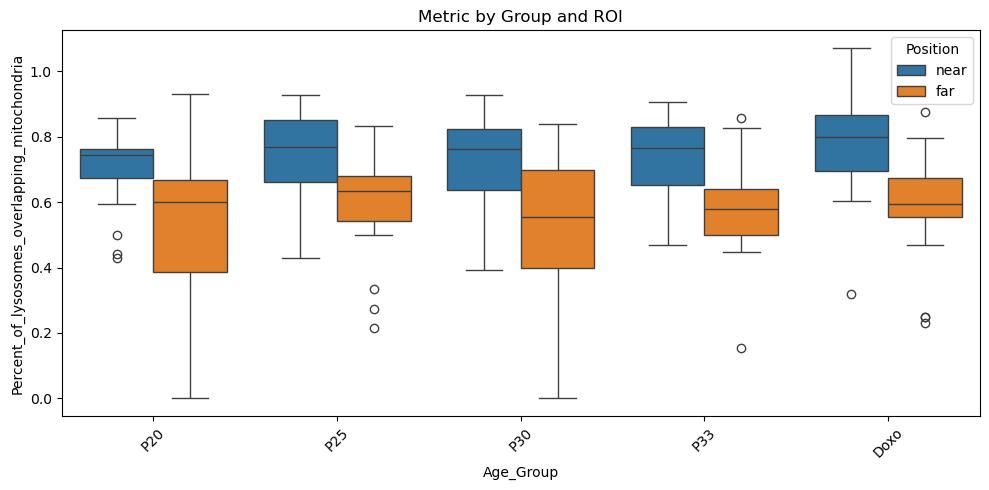

<Axes: xlabel='Age_Group', ylabel='Percent_of_lysosomes_overlapping_mitochondria'>

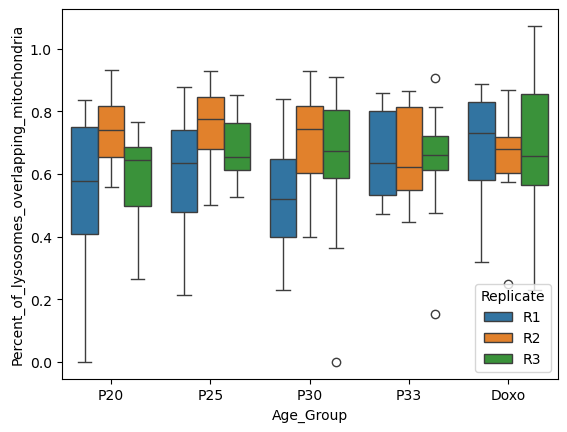

In [15]:

def plot_boxplots(df, group_col, roi_col, value_col, roi_values=None, title=None):
    plot_data = prepare_boxplot_data(df, group_col, roi_col, value_col, roi_values=roi_values)

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=plot_data, x=group_col, y=value_col, hue=roi_col)
    plt.xticks(rotation=45)
    plt.title(title or f"Boxplot of {value_col} by {group_col} and {roi_col}")
    plt.tight_layout()
    #return plt.gcf()

# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
# Uncomment the line below to generate a boxplot
plot_boxplots(combined_df, GROUP_COL, ROI_COL, VALUE_COL, roi_values=ROI_VALUES, title="Metric by Group and ROI")
plt.show()
sns.boxplot(data=combined_df, x=GROUP_COL, y=VALUE_COL, hue="Replicate")
# Preview outputs


[('P20', 'P25'), ('P20', 'P30'), ('P20', 'P33'), ('P20', 'Doxo'), ('P25', 'P30'), ('P25', 'P33'), ('P25', 'Doxo'), ('P30', 'P33'), ('P30', 'Doxo'), ('P33', 'Doxo')]
tukey
ANOVA F statistic: nan
ANOVA p value: nan
ANOVA test is not significant, skipping Tukey's HSD post-hoc test.
No significant pairs found for the tukey test.


/Users/allielas/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:333: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_value, p_value_anova = f_oneway(


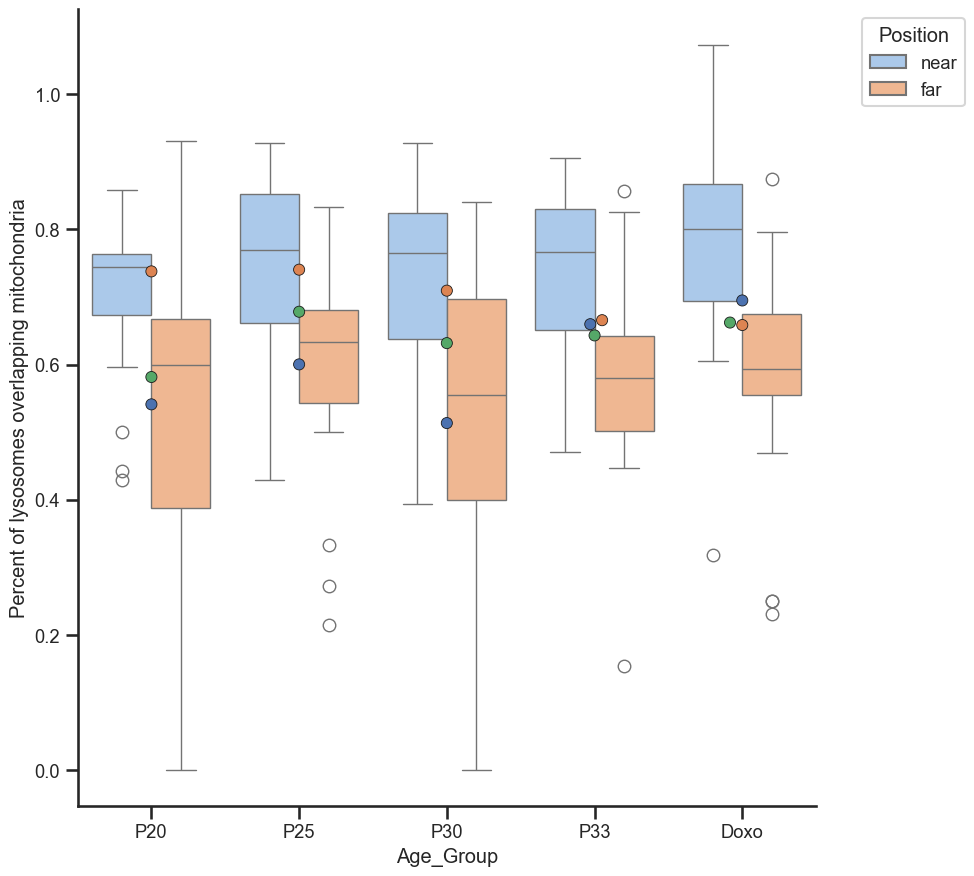

In [30]:
def simple_paired_superboxplot_with_annotation(
    data_df,
    x_value,
    y_value,
    hue_value,
    plate_col_name="Replicate",
    pairs=None,
    order=None,
    annotate=False,
    test="tukey",
    ytitle=None,
    xtitle=None,
    ylim=None,
    pallete="Set2",
    figsize=(10, 9),
    context="talk",
    dpi=300,
    legend=False,
):
    # Set values to defaults if a parameter is not loaded for order or y axis parameters
    if ytitle is None:
        ytitle = y_value.replace("_", " ")
    if order is None:
        order = data_df[x_value].dropna().unique().tolist()
    if xtitle is None:
        xtitle = x_value

    pairs = getpairs(data_df, x_value, order)
    print(pairs)

    if x_value == "AllGroups":
        order = get_all_group_order()

    group_avg_df = (
        data_df.groupby([x_value, plate_col_name], dropna=False)[y_value]
        .agg("mean")
        .reset_index()
    )

    # Pivot table: rows = Group, columns = ROI
    group_avg_df_pivot = (
        group_avg_df.pivot(index=[x_value], columns=plate_col_name, values=y_value)
        .reindex(columns=ROI_VALUES)
    )


    sns.set_theme(style="ticks")
    plt.figure(figsize=figsize)  # , dpi=dpi)
    sns.set_context(context, font_scale=0.8)

    sns.boxplot(
            data=data_df,
            x=x_value,
            y=y_value,
            hue=hue_value,
            order=order,
            palette="pastel",
            dodge=True,
        )
    ax = sns.swarmplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        hue=plate_col_name,
        order=order,
        palette=pallete,
        dodge=False,
        size=8,
        edgecolor="k",
        linewidth=0.6,
        legend=False
    )
    
    if legend:
        ax.legend(title=hue_value, bbox_to_anchor=(1.05, 1), loc="upper left")
        # ax = annotate_legend_with_shapiro(ax, group_avg_df_shapiro, plate_col_name)
    else:
        ax.legend_.remove()
        # ax.legend_.remove()

    sns.despine()
    plt.tight_layout()
    plt.xlabel(xtitle)
    plt.ylabel(ytitle)
    plt.ylim(ylim)
    if annotate and test is not None:
        try:
            print(test)
            ax = annotate_pairs_with_calculated_pvalues(
                ax,
                group_avg_df,
                group_avg_df_pivot,
                x_value,
                y_value,
                plate_col_name=plate_col_name,
                test_name=test,
                order=order,
                plot_type="swarmplot",
            )
        except Exception as e:
            print(f"Error annotating with statistical test: {e}")

    plt.savefig(xtitle + "_" + y_value + "_swarmplot.png", dpi=dpi)
    plt.show()

simple_superswarmplot = simple_paired_superboxplot_with_annotation(
    data_df=combined_df,
    x_value=GROUP_COL,
    y_value=VALUE_COL,
    hue_value=ROI_COL,
    plate_col_name="Replicate",
    pairs=None,
    order=None,
    annotate=True,
    test="tukey",
    ytitle=None,
    xtitle=None,
    ylim=None,
    pallete=None,
    figsize=(10, 9),
    context="talk",
    dpi=300,
    legend=True,
)